# PyTorch MLP on Fashion-MNIST
We train on Fashion-MNIST with `CrossEntropyLoss` + `Adam` and the canonical five-line loop:

1. `y_hat = model(x)`
2. `loss = criterion(y_hat, y)`
3. `optimizer.zero_grad()`
4. `loss.backward()`
5. `optimizer.step()`

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

torch.manual_seed(0)

output_dir = 'outputs'
os.makedirs(output_dir, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('using device', device)

using device cpu


## Data: Fashion-MNIST

Fashion-MNIST is a 28x28 grayscale clothing images in 10 classes. Pixels are scaled to floats in [0, 1] by `ToTensor`.

In [2]:
data_root = os.path.join(output_dir, 'fashion_mnist')
transform = transforms.ToTensor()

train_set = datasets.FashionMNIST(root=data_root, train=True, download=True, transform=transform)
test_set = datasets.FashionMNIST(root=data_root, train=False, download=True, transform=transform)

train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
test_loader = DataLoader(test_set, batch_size=256, shuffle=False)

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print('train size', len(train_set))
print('test size', len(test_set))

  0%|          | 0.00/26.4M [00:00<?, ?B/s]

  0%|          | 32.8k/26.4M [00:00<07:38, 57.5kB/s]

  0%|          | 65.5k/26.4M [00:01<10:57, 40.1kB/s]

  0%|          | 98.3k/26.4M [00:01<07:40, 57.2kB/s]

  1%|          | 164k/26.4M [00:02<04:22, 100kB/s]  

...

 99%|█████████▉| 4.39M/4.42M [00:20<00:00, 237kB/s]

100%|██████████| 4.42M/4.42M [00:20<00:00, 212kB/s]

  0%|          | 0.00/5.15k [00:00<?, ?B/s]

100%|██████████| 5.15k/5.15k [00:00<00:00, 336kB/s]

train size 60000
test size 10000


Quick peek at the data here....


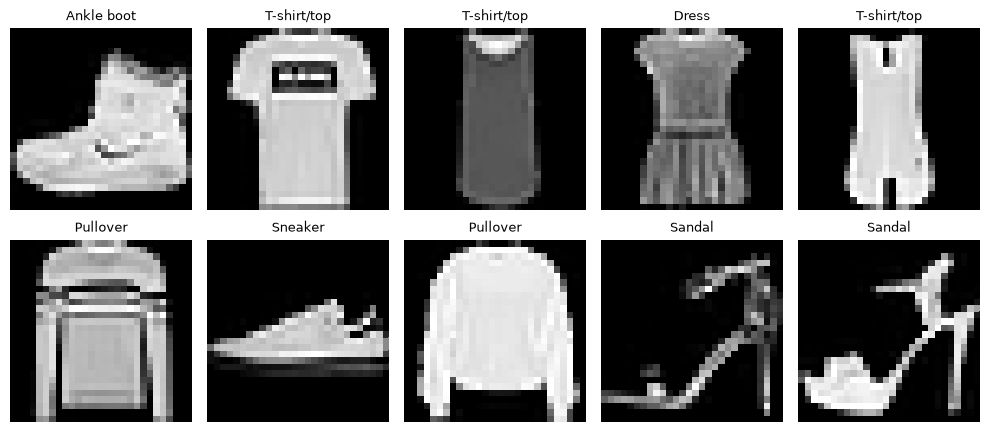

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4.5))
for ax, (img, label) in zip(axes.ravel(), train_set):
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(class_names[label], fontsize=9)
    ax.axis('off')
fig.tight_layout()
fig.savefig(os.path.join(output_dir, 'nb3_fashion_samples.png'), dpi=140)
plt.show()

## Model: an MLP as an `nn.Module` 

Here, we flatten the 28x28 image to a 784-vector, one hidden layer with ReLU, then 10 logits for `CrossEntropyLoss`.

In [4]:
class MlpClassifier(nn.Module):
    def __init__(self, in_dim=784, hidden=128, n_classes=10):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(in_dim, hidden)
        self.act = nn.ReLU()
        self.fc2 = nn.Linear(hidden, n_classes)

    def forward(self, x):
        x = self.flatten(x)
        x = self.act(self.fc1(x))
        return self.fc2(x)

model = MlpClassifier().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

n_params = sum(p.numel() for p in model.parameters())
print('parameters', n_params)

parameters 101770


## Training loop 

This five-line loop in `trainOneEpoch` is a general pattern you may find useful for Day 3 and Day 4 type work

In [5]:
def trainOneEpoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    correct = 0
    seen = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        y_hat = model(x)
        loss = criterion(y_hat, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * x.size(0)
        correct += (y_hat.argmax(dim=1) == y).sum().item()
        seen += x.size(0)
    return running_loss / seen, correct / seen

def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    seen = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            y_hat = model(x)
            loss = criterion(y_hat, y)
            running_loss += loss.item() * x.size(0)
            correct += (y_hat.argmax(dim=1) == y).sum().item()
            seen += x.size(0)
    return running_loss / seen, correct / seen

In [6]:
epochs = 5
train_losses, train_accs = [], []
test_losses, test_accs = [], []

for epoch in range(1, epochs + 1):
    tr_loss, tr_acc = trainOneEpoch(model, train_loader, criterion, optimizer)
    te_loss, te_acc = evaluate(model, test_loader, criterion)
    train_losses.append(tr_loss)
    train_accs.append(tr_acc)
    test_losses.append(te_loss)
    test_accs.append(te_acc)
    print(f'epoch {epoch} train_loss {tr_loss:.4f} train_acc {tr_acc:.4f} test_loss {te_loss:.4f} test_acc {te_acc:.4f}')

epoch 1 train_loss 0.5902 train_acc 0.8004 test_loss 0.4841 test_acc 0.8255


epoch 2 train_loss 0.4205 train_acc 0.8535 test_loss 0.4297 test_acc 0.8478


epoch 3 train_loss 0.3804 train_acc 0.8666 test_loss 0.4017 test_acc 0.8581


epoch 4 train_loss 0.3537 train_acc 0.8738 test_loss 0.3900 test_acc 0.8637


epoch 5 train_loss 0.3340 train_acc 0.8805 test_loss 0.3926 test_acc 0.8619


## Loss and accuracy curves

Train and test together 

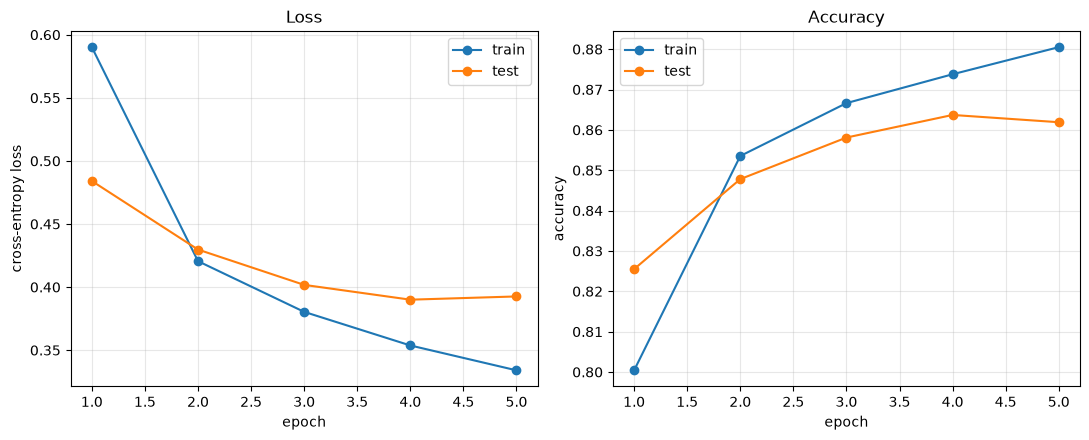

In [7]:
epochs_axis = list(range(1, epochs + 1))
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].plot(epochs_axis, train_losses, marker='o', label='train')
axes[0].plot(epochs_axis, test_losses, marker='o', label='test')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('cross-entropy loss')
axes[0].set_title('Loss')
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(epochs_axis, train_accs, marker='o', label='train')
axes[1].plot(epochs_axis, test_accs, marker='o', label='test')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('accuracy')
axes[1].set_title('Accuracy')
axes[1].grid(alpha=0.3)
axes[1].legend()

fig.tight_layout()
fig.savefig(os.path.join(output_dir, 'nb3_training_curves.png'), dpi=140)
plt.show()

## Predictions on a few test images

Sanity check that the model is doing the thing the loss curve suggests.

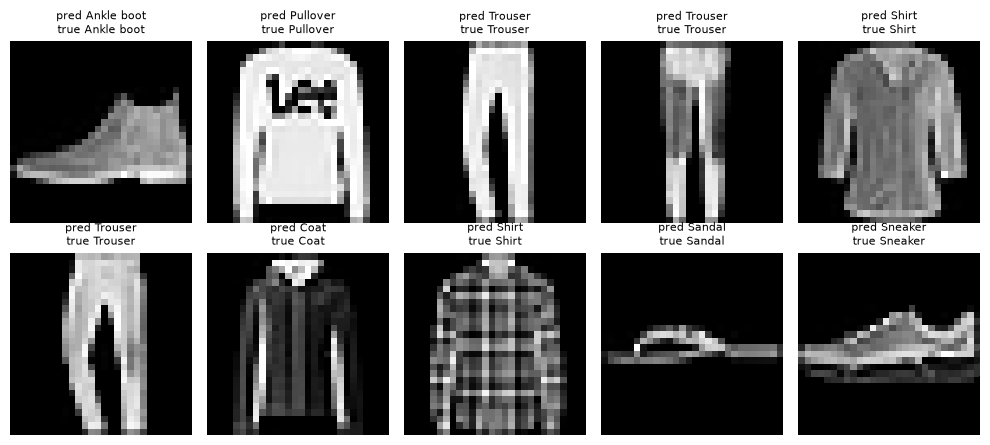

In [8]:
model.eval()
images, labels = next(iter(test_loader))
with torch.no_grad():
    preds = model(images.to(device)).argmax(dim=1).cpu()

fig, axes = plt.subplots(2, 5, figsize=(10, 4.5))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(images[i].squeeze(), cmap='gray')
    true_name = class_names[labels[i].item()]
    pred_name = class_names[preds[i].item()]
    color = 'black' if true_name == pred_name else 'tab:red'
    ax.set_title(f'pred {pred_name}\ntrue {true_name}', fontsize=8, color=color)
    ax.axis('off')
fig.tight_layout()
fig.savefig(os.path.join(output_dir, 'nb3_predictions.png'), dpi=140)
plt.show()